In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
#Import the Dataset
df= pd.read_csv("../dataset/English-ONLY.csv")
df.head()

,email_text,email_type
0,Hello I am your hot lil horny toy.\n I am t...,Phishing Email
1,"On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...",Safe Email
2,"URL: http://www.newsisfree.com/click/-5,830431...",Safe Email
3,"begin forwarded text Date: Wed, 25 Sep 2002 13...",Safe Email
4,The academic discipline of Software Engineerin...,Safe Email


In [4]:
# Check NAN values
df.isna().sum()

email_text    0
email_type    0
dtype: int64

In [5]:
#Drop tha Na values
df = df.dropna()
print(df.isna().sum())

email_text    0
email_type    0
dtype: int64


In [6]:
#dataset shape
df.shape

(1484, 2)

In [7]:
# # Count the occurrences of each E-mail type. 
email_type_counts = df['email_type'].value_counts()
print(email_type_counts)

email_type
Safe Email        1232
Phishing Email     252
Name: count, dtype: int64


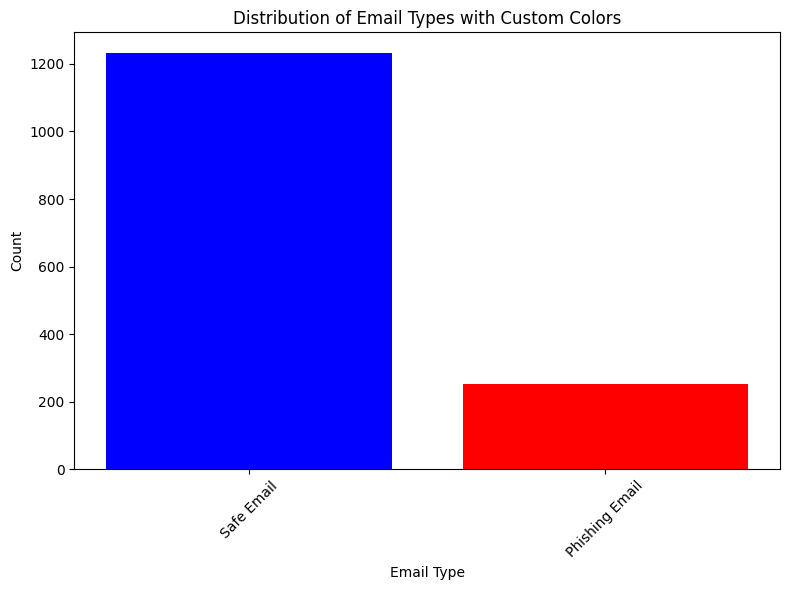

In [8]:
# Create the bar chart
# Create a list of unique email types
unique_email_types = email_type_counts.index.tolist()

# Define a custom color map 
color_map = {
    'Phishing Email': 'red',
    'Safe Email': 'blue',}

# Map the colors to each email type
colors = [color_map.get(email_type, 'gray') for email_type in unique_email_types]

# Create the bar chart with custom colors
plt.figure(figsize=(8, 6))
plt.bar(unique_email_types, email_type_counts, color=colors)
plt.xlabel('Email Type')
plt.ylabel('Count')
plt.title('Distribution of Email Types with Custom Colors')
plt.xticks(rotation=45)

# Show the chart
plt.tight_layout()
plt.show()

In [9]:
# # We will use undersapling technique 
Safe_Email = df[df["email_type"]== "Safe Email"]
Phishing_Email = df[df["email_type"]== "Phishing Email"]
Safe_Email = Safe_Email.sample(Phishing_Email.shape[0])

In [10]:
# lets check the sahpe again 
Safe_Email.shape,Phishing_Email.shape

((252, 2), (252, 2))

In [11]:
# lest create a new Data with the balanced E-mail types
Data= pd.concat([Safe_Email, Phishing_Email], ignore_index = True)
Data.head()

,email_text,email_type
0,"URL: http://www.newsisfree.com/click/-1,841205...",Safe Email
1,URL: http://boingboing.net/#85539452\nDate: No...,Safe Email
2,use Perl Daily NewsletterIn this issue:\n *...,Safe Email
3,"This is my first time running Razor, heard a l...",Safe Email
4,I know I heard of this a few years back but Wi...,Safe Email


In [12]:
# # split the data into a metrix of features X and Dependent Variable y
X = Data["email_text"].values
y = Data["email_type"].values

In [13]:
# lets splitting Our Data 
from sklearn.model_selection import train_test_split
X_train,x_test,y_train,y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [14]:
# Importing Libraries for the model ,Tfidf and Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

# define the Classifier
classifier = Pipeline([("tfidf",TfidfVectorizer()),("classifier",RandomForestClassifier(class_weight='balanced',n_estimators=10))])# add another hyperparamters as U want

In [15]:
# Trian Our model
classifier.fit(X_train,y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=10))])

In [16]:
# Prediction
y_pred = classifier.predict(x_test)

In [17]:
# Importing classification_report,accuracy_score,confusion_matrix
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,recall_score,precision_score

In [18]:
#accuracy_score
accuracy = accuracy_score(y_test,y_pred)

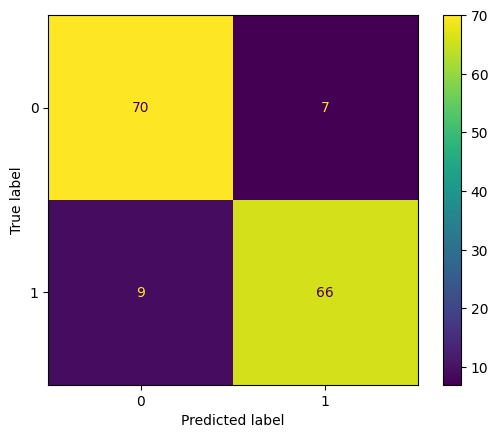

In [19]:
#confusion_matrix
conf = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(confusion_matrix=conf).plot()

In [20]:
precision = precision_score(y_test, y_pred,pos_label="Phishing Email")
recall = recall_score(y_test, y_pred,pos_label="Phishing Email")

In [21]:
# record accuracy in file
with open("english_only_RF_result.txt", "a") as file:
    file.write(f"\n  Model Accuracy: {accuracy:.2f}\n Recall:{recall:.2f}\n Precision:{precision:.2f} \n Confusion matrix: \n{conf}")